# Add a frame to a photo

## Define the code and necessary imports

In [1]:
# Import the function from the script
import sys
from pathlib import Path
# Ensure repo root is in path (optional)
sys.path.insert(0, str(Path.cwd()))
from add_border import add_border
print('add_border imported successfully')

add_border imported successfully


In [2]:
# Instagram square 1080x1080 px
instagram_square_dimensions = {
    'width': 1080,
    'height': 1080
}
square_padding = {
    'pad_top': 40,
    'pad_bottom': 40,
    'pad_left': 40,
    'pad_right': 40
}

# Instagram portrait 4:5 1080x1350 px
instagram_portrait_dimensions = {
    'width': 1080,
    'height': 1350
}
portrait_padding = {
    'pad_top': 40,
    'pad_bottom': 40,
    'pad_left': 40,
    'pad_right': 40
}

# Instagram landscape 1.91:1 1080x566 px
instagram_landscape_dimensions = {
    'width': 1080,
    'height': 566
}
landscape_padding = {
    'pad_top': 40,
    'pad_bottom': 40,
    'pad_left': 40,
    'pad_right': 40
}

# Output type dict
output_settings = {
    'square': {
        'dimensions': instagram_square_dimensions,
        'padding': square_padding
    },
    'landscape': {
        'dimensions': instagram_landscape_dimensions,
        'padding': landscape_padding
    },
    'portrait': {
        'dimensions': instagram_portrait_dimensions,
        'padding': portrait_padding
    }
}

### Definition `frame_photo`

Connect all the inputs and necessary dimensions for the three types of output images.

In [3]:
import os
from IPython.display import display
from PIL import Image

def frame_photo(
        input_file: str,
        output_type: str, # one of 'square', 'landscape', 'portrait'
        bg_color: str = 'white',
        quality: int = 95,
        output_suffix: str = '_border'
):
    """
    Adds a frame to a photo
    Params:
        input_file: Absolute path the image file
        output_type: 'square', 'portrait', or 'landscape'
        bg_color: background color, default is 'white'
        quality: 95 (default)
        output_suffix: '_border'
    """
    name, ext = os.path.splitext(os.path.basename(input_file))
    output_file = f"{os.path.dirname(input_file)}/{name}{output_suffix}{ext}"
    dimensions = output_settings[output_type]['dimensions']
    padding = output_settings[output_type]['padding']

    print('Input:', input_file)
    print('Output:', output_file)
    print('Canvas:', dimensions['width'], 'x', dimensions['height'])
    print('Padding (Left/Right):', padding['pad_left'], padding['pad_right'])
    print('Padding (Top/Bottom):', padding['pad_top'], padding['pad_bottom'])

    try:
        # Add the borders
        add_border(
            input_path=input_file,
            output_path=output_file,
            final_w=dimensions['width'],
            final_h=dimensions['height'],
            pad_top=padding['pad_top'],
            pad_bottom=padding['pad_bottom'],
            pad_left=padding['pad_left'],
            pad_right=padding['pad_right'],
            bg_color=bg_color,
            quality=quality
        )
    
        # Display output if created
        img = Image.open(output_file)
        print('Output image size:', img.size, 'mode:', img.mode)
        display(img)
    except FileNotFoundError:
        print('Output file was not created. Check the input path and parameters.')


### Testing
Optional to run and check

In [ ]:
# Testing
import glob

files = glob.glob('./testing_images/*.jpg')
for file in files:
    frame_photo(input_file=file, output_type='portrait')




In [ ]:
# Clear the output files after testing
output_files = glob.glob('./testing_images/*_border.jpg')
for output_file in output_files:
    if os.path.exists(output_file):
        os.remove(output_file)
        print(f"File {output_file} deleted!")

## Usage

Input: /Users/adm/Pictures/instagram/candidates/sadguru.jpeg
Output: /Users/adm/Pictures/instagram/candidates/sadguru_border.jpeg
Canvas: 1080 x 1350
Padding (Left/Right): 40 40
Padding (Top/Bottom): 40 40
Output image size: (1080, 1350) mode: RGB


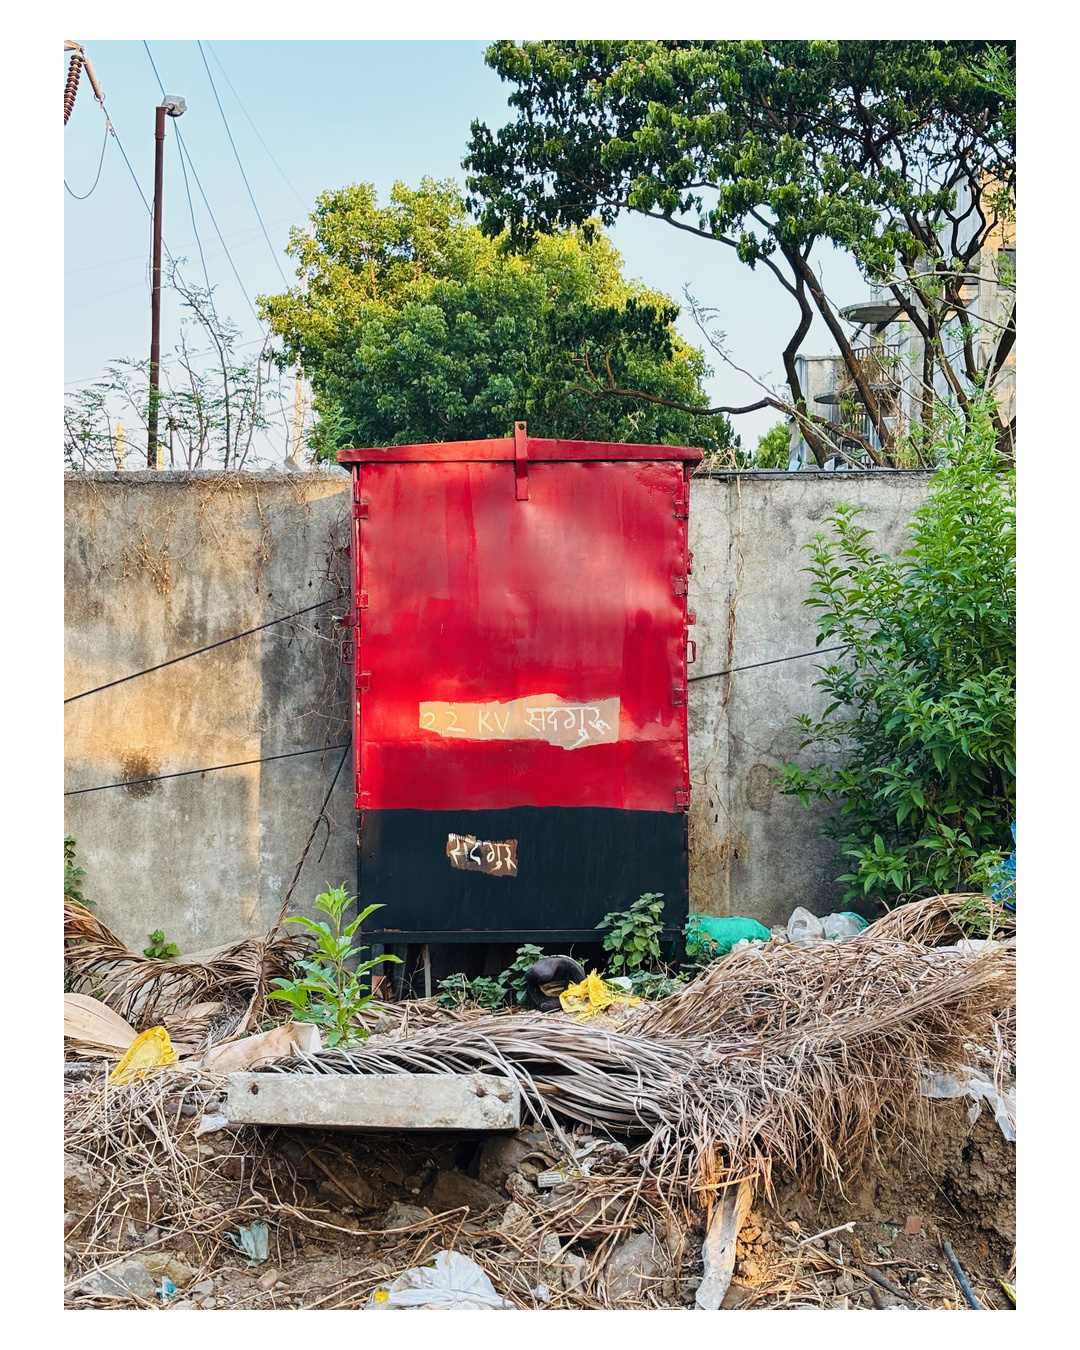

In [4]:
frame_photo(
    input_file='/Users/adm/Pictures/instagram/candidates/sadguru.jpeg',
    output_type='portrait', # 'portrait' or 'square' or 'landscape'
)

## Legacy

In [ ]:
# --- INPUTS: edit these values before running the demo ---
# Provide an existing JPG path on your machine
input_path = '/Volumes/T5 EVO/Photos/2025/20251019-Lausanne-Ouchy/Output/20251019-Lausanne-Ouchy-0002_instagram.jpg'  # <-- change this to a valid path
# Output path can be relative to this repository or an absolute path
output_path = '/Volumes/T5 EVO/Photos/2025/20251019-Lausanne-Ouchy/Output/20251019-Lausanne-Ouchy-0002_instagram_border.jpg'
# Final canvas dimensions

width = instagram_square_dimensions['width']
height = instagram_square_dimensions['height']

photo_orientation = 'landscape' # or 'portrait'
padding = padding_type[photo_orientation]
# Left and right padding (pixels)
pad_left = padding['pad_left']
pad_right = padding['pad_right']
# Optional: top/bottom padding. Set to None to auto-center vertically
pad_top = None
pad_bottom = None
# Background color and JPEG quality
bg_color = 'white'
quality = 95
# ---------------------------------------------------------

# Sanity print
print('Input:', input_path)
print('Output:', output_path)
print('Canvas:', width, 'x', height, 'pad L/R:', pad_left, pad_right)

In [ ]:
# Run the function and display the resulting image (if successful)
from IPython.display import display
from PIL import Image

# Call the function
add_border(input_path, output_path, width, height, pad_left, pad_right, pad_top=pad_top, pad_bottom=pad_bottom, bg_color=bg_color, quality=quality)

# Display output if created
try:
    img = Image.open(output_path)
    print('Output image size:', img.size, 'mode:', img.mode)
    display(img)
except FileNotFoundError:
    print('Output file was not created. Check the input path and parameters.')

## Notes & Tips
- If your input path is on an external drive or contains spaces, ensure the path is correct.
- Use `pad_top`/`pad_bottom` to control vertical placement; leave them as `None` to auto-center vertically.
- To change border color, set `bg_color` to a CSS name (e.g., `white`, `black`) or a hex string (e.g., `#ffffff`).
- If you want, I can add a small sample image to the repo for a runnable demo or run this notebook here to verify output — tell me which you prefer.